Imports

In [109]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from siphon.catalog import TDSCatalog
import metpy.calc as mpcalc
from metpy.units import units
from scipy.ndimage import gaussian_filter
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import time as datetime
from matplotlib.patheffects import withStroke

Import a couple of functions from data_processing.py under the pre-processing directory

In [85]:
import sys
from pathlib import Path

sys.path.append(str(Path(r"C:\Users\Tony\Documents\GitHub\EAE-598-Project\pre_processing")))
from data_processing import load_local_datasets, slice_dataset_to_domain

Define event information including date and location

        {"year": 2017, "month": 11, "start_day": 19, "start_hour": 3, "lat": 38, "lon": 142.5, "label": "MFW"},


In [86]:
year = 2017 #yyyy
month = 11 #mm
day = 19 #dd
start_hour = 3 #hh
end_hour = start_hour + 1

directions = {'North': 55, 'East': 250, 'South': 20, 'West': 200}  # units: degrees North, degrees East
point_lat, point_lon = 38, 142.5 # units: degrees North, degrees West
buffer = 0.25  # units: degrees
point_lon_e = 360 - point_lon
point_lon_e
box_north = point_lat + buffer
box_south = point_lat - buffer
box_east = point_lon_e + buffer
box_west = point_lon_e - buffer

g = 9.81  # units: m/s^2

Load pressure and surface level datasets

In [87]:
ds_pl, ds_sfc = load_local_datasets(year, month, day, start_hour)

Let's check the datasets

In [88]:
ds_pl

<xarray.Dataset>
Dimensions:    (latitude: 141, level: 37, longitude: 201)
Coordinates:
  * latitude   (latitude) float64 55.0 54.75 54.5 54.25 ... 20.5 20.25 20.0
  * level      (level) float64 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * longitude  (longitude) float64 200.0 200.2 200.5 200.8 ... 249.5 249.8 250.0
    time       datetime64[ns] ...
Data variables:
    utc_date   int32 ...
    T          (level, latitude, longitude) float32 ...
    Z          (level, latitude, longitude) float32 ...
    Q          (level, latitude, longitude) float32 ...
    V          (level, latitude, longitude) float32 ...
    U          (level, latitude, longitude) float32 ...
    W          (level, latitude, longitude) float32 ...
    PV         (level, latitude, longitude) float32 ...
Attributes:
    DATA_SOURCE:                     ECMWF: https://cds.climate.copernicus.eu...
    NETCDF_CONVERSION:               CISL RDA: Conversion from ECMWF GRIB 1 d...
    NETCDF_VERSION:                  4.6.3
    CONVERSION_PLATFORM:             Linux r9i2n26 4.12.14-94.41-default #1 S...
    CONVERSION_DATE:                 Fri Sep  6 13:06:14 MDT 2019
    Conventions:                     CF-1.6
    NETCDF_COMPRESSION:              NCO: Precision-preserving compression to...
    history:                         Fri Sep  6 13:06:31 2019: ncks -4 --ppc ...
    NCO:                             netCDF Operators version 4.7.9 (Homepage...
    DODS_EXTRA.Unlimited_Dimension:  time

Looks good

In [89]:
ds_sfc

<xarray.Dataset>
Dimensions:    (latitude: 141, longitude: 201)
Coordinates:
  * latitude   (latitude) float64 55.0 54.75 54.5 54.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 200.0 200.2 200.5 200.8 ... 249.5 249.8 250.0
    time       datetime64[ns] ...
Data variables:
    utc_date   int32 ...
    MSL        (latitude, longitude) float32 ...
    V10N       (latitude, longitude) float32 ...
    U10N       (latitude, longitude) float32 ...
    VAR_2T     (latitude, longitude) float32 ...
    VAR_2D     (latitude, longitude) float32 ...
Attributes:
    DATA_SOURCE:                     ECMWF: https://cds.climate.copernicus.eu...
    NETCDF_CONVERSION:               CISL RDA: Conversion from ECMWF GRIB1 da...
    NETCDF_VERSION:                  4.6.3
    CONVERSION_PLATFORM:             Linux r10i3n26 4.12.14-94.41-default #1 ...
    CONVERSION_DATE:                 Fri Sep  6 11:57:37 MDT 2019
    Conventions:                     CF-1.6
    NETCDF_COMPRESSION:              NCO: Precision-preserving compression to...
    history:                         Fri Sep  6 11:57:54 2019: ncks -4 --ppc ...
    NCO:                             netCDF Operators version 4.7.9 (Homepage...
    DODS_EXTRA.Unlimited_Dimension:  time

Also looks good

Let's make a basemap defined function that can be called for plotting purposes

In [102]:
def base_plot(directions):
    fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([directions['West'], directions['East'], directions['South'], directions['North']-5])
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, color='white')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, color='#fbf5e9')
    
    # Add gridlines and format longitude/latitude labels
    gls = ax.gridlines(draw_labels=True, color='black', linestyle='--', alpha=0.35)
    gls.top_labels = False
    gls.right_labels = False
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    
    return fig, ax

C:\Users\Tony\AppData\Local\Temp\ipykernel_4636\2595377698.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


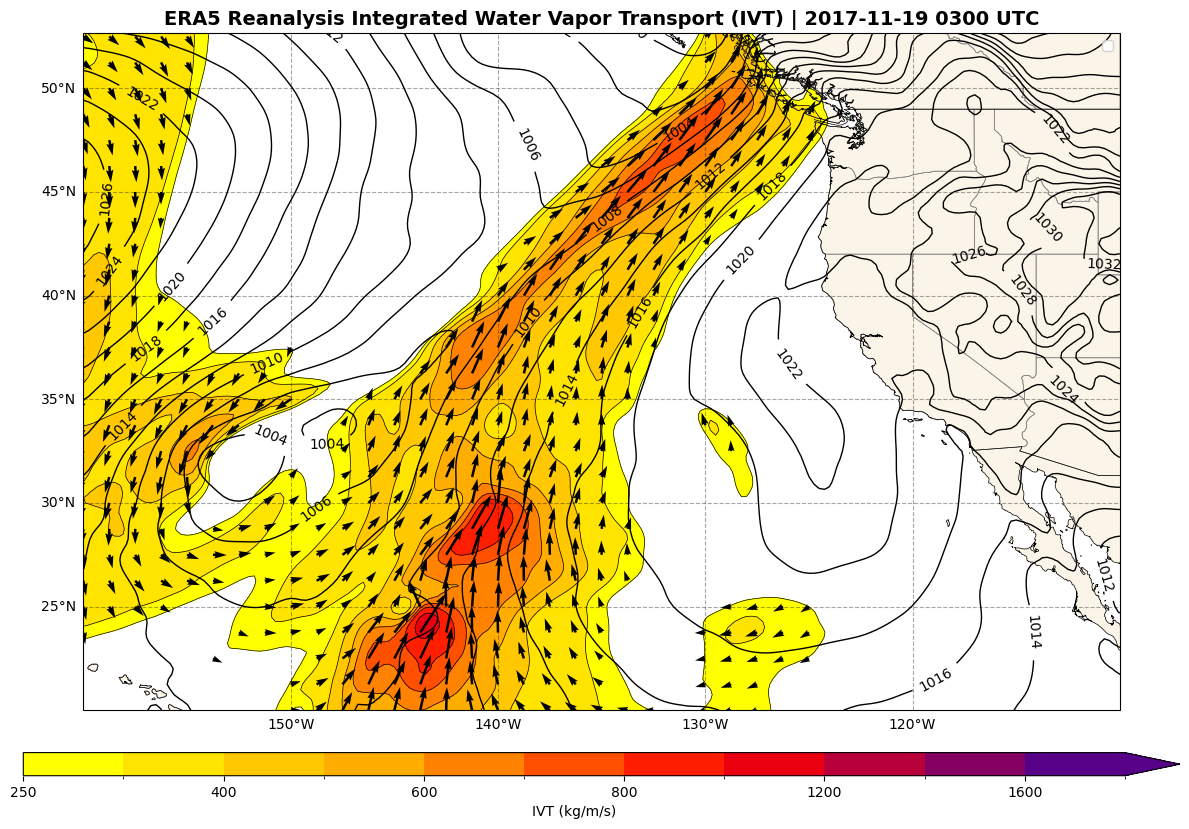

In [164]:
# Slice the dataset to get the data for the pressure levels between 500 and 1000 hPa
u_sliced = ds_pl['U'].sel(level=slice(500, 1000)) # units: m/s
v_sliced = ds_pl['V'].sel(level=slice(500, 1000)) # units: m/s
q_sliced = ds_pl['Q'].sel(level=slice(500, 1000)) # units: kg/kg
mslp = ds_sfc['MSL'] / 100 # units: hPa

# Flip the order of the pressure levels and convert them to Pa from hPa
pressure_levels = u_sliced['level'][::-1] * 100 * units.Pa # units: Pa

# Get the time of the current time step and create a pandas DatetimeIndex
time = ds_pl.time.values
int_datetime_index = pd.DatetimeIndex([time])

lats, lons = ds_pl['latitude'].metpy.unit_array, ds_pl['longitude'].metpy.unit_array

# Calculate the integrated vapor transport (IVT) using the u- and v-wind components and the specific humidity
u_ivt = -1 / g * np.trapz(u_sliced * q_sliced, pressure_levels, axis=0)
v_ivt = -1 / g * np.trapz(v_sliced * q_sliced, pressure_levels, axis=0)

# Calculate the IVT magnitude
ivt = np.sqrt(u_ivt**2 + v_ivt**2)

# Create an xarray DataArray for the IVT
ivt_da = xr.DataArray(ivt, dims=['latitude', 'longitude'], coords={'latitude': u_sliced['latitude'], 'longitude': u_sliced['longitude']})

# Define the color levels and colors for the IVT plot
levels = [250, 300, 400, 500, 600, 700, 800, 1000, 1200, 1400, 1600, 1800]
colors = ['#ffff00', '#ffe400', '#ffc800', '#ffad00', '#ff8200', '#ff5000', '#ff1e00', '#eb0010', '#b8003a', '#850063', '#570088']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, cmap.N)

# Get the time of the current time step and create a pandas DatetimeIndex
time = ds_pl.time.values
int_datetime_index = pd.DatetimeIndex([time])

# Smooth the data
ivt_smoothed = gaussian_filter(ivt_da, sigma=1)
u_ivt_smoothed = gaussian_filter(u_ivt, sigma=1)
v_ivt_smoothed = gaussian_filter(v_ivt, sigma=1)
mslp_smoothed = gaussian_filter(mslp, sigma=1)

# Mask the IVT values below 250 kg/m/s and create a filtered DataArray for the u- and v-wind components
mask = ivt_da >= 250
u_ivt_filtered = xr.DataArray(u_ivt, dims=['latitude', 'longitude'], coords={'latitude': u_sliced['latitude'], 'longitude': u_sliced['longitude']}).where(mask, drop=True)
v_ivt_filtered = xr.DataArray(v_ivt, dims=['latitude', 'longitude'], coords={'latitude': u_sliced['latitude'], 'longitude': u_sliced['longitude']}).where(mask, drop=True)

# Plot
fig, ax = base_plot(directions)
plt.contour(lons, lats, ivt_smoothed, colors='black', levels=levels, linewidths=0.5)
cf = ax.contourf(lons, lats, ivt_smoothed, levels=levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())
plt.colorbar(cf, orientation='horizontal', label="IVT (kg/m/s)", pad=0.05, aspect=50)
isobars = plt.contour(lons, lats, mslp_smoothed, colors='black', levels=np.arange(960, 1080, 2), linewidths=1)
try:
    plt.clabel(isobars, inline=True, inline_spacing=5, fontsize=10, fmt='%i')
except IndexError:
    print("No contours to label for isobars.")

step = 5 
plt.quiver(u_ivt_filtered['longitude'].values[::step], u_ivt_filtered['latitude'].values[::step], u_ivt_filtered.values[::step, ::step], v_ivt_filtered.values[::step, ::step], scale=500, scale_units='xy', color='black')

ax.legend(loc='upper right', fontsize=10)

plt.title(f'ERA5 Reanalysis Integrated Water Vapor Transport (IVT) | {int_datetime_index[0].strftime("%Y-%m-%d %H00 UTC")}', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

Fine but let's make it look nicer and focus on the location we are computing the area-average

Increase the buffer size for plotting purposes only (increases readability)

In [165]:
main_plot_buffer = 0.675  # Increase the buffer for the main plot
inset_buffer = 0.25  # Keep the original buffer for the inset

# Update the box boundaries for the main plot
main_box_north = point_lat + main_plot_buffer
main_box_south = point_lat - main_plot_buffer
main_box_east = point_lon_e + main_plot_buffer
main_box_west = point_lon_e - main_plot_buffer

C:\Users\Tony\AppData\Local\Temp\ipykernel_4636\3124016439.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


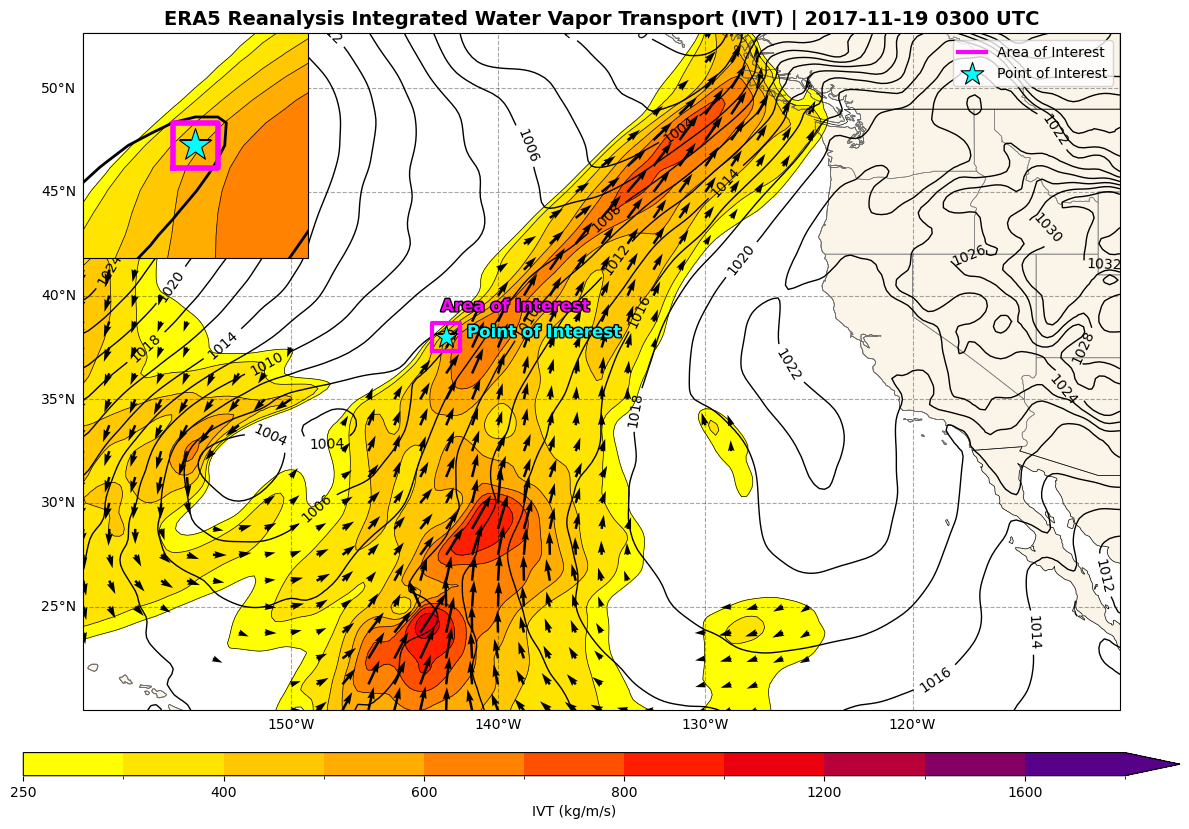

In [167]:
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([directions['West'], directions['East'], directions['South'], directions['North']-5])
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='white')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, color='#fbf5e9')

# Add gridlines and format longitude/latitude labels
gls = ax.gridlines(draw_labels=True, color='black', linestyle='--', alpha=0.35)
gls.top_labels = False
gls.right_labels = False
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)


ax.contour(lons, lats, ivt_smoothed, colors='black', levels=levels, linewidths=0.5)
cf = ax.contourf(lons, lats, ivt_smoothed, levels=levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())
isobars = ax.contour(lons, lats, mslp_smoothed, colors='black', levels=np.arange(960, 1080, 2), linewidths=1)
try:
    ax.clabel(isobars, inline=True, inline_spacing=5, fontsize=10, fmt='%i')
except IndexError:
    print("No contours to label for isobars.")

step = 5  
ax.quiver(
    u_ivt_filtered['longitude'].values[::step], u_ivt_filtered['latitude'].values[::step],
    u_ivt_filtered.values[::step, ::step], v_ivt_filtered.values[::step, ::step],
    scale=500, scale_units='xy', color='black', transform=ccrs.PlateCarree())

ax.plot(
    [main_box_west, main_box_east, main_box_east, main_box_west, main_box_west],
    [main_box_south, main_box_south, main_box_north, main_box_north, main_box_south],
    color='magenta', linewidth=3, linestyle='-', transform=ccrs.PlateCarree(), label='Area of Interest')
ax.scatter(point_lon_e, point_lat, color='cyan', s=300, marker='*', edgecolor='black', linewidth=0.75, transform=ccrs.PlateCarree(), label='Point of Interest', zorder=99)

outline_effect = [withStroke(linewidth=2, foreground='black')]
ax.text(point_lon_e + 1, point_lat, 'Point of Interest', color='cyan', fontsize=12, fontweight='bold', transform=ccrs.PlateCarree(), path_effects=outline_effect, zorder=98)
ax.text(box_west, box_north + 1, 'Area of Interest', color='magenta', fontsize=12, fontweight='bold', transform=ccrs.PlateCarree(), path_effects=outline_effect, zorder=98)
ax.legend(loc='upper right', fontsize=10)

plt.colorbar(cf, orientation='horizontal', label="IVT (kg/m/s)", pad=0.05, aspect=50)
plt.title(f'ERA5 Reanalysis Integrated Water Vapor Transport (IVT) | {int_datetime_index[0].strftime("%Y-%m-%d %H00 UTC")}', fontsize=14, weight='bold')

# Inset map
ax_inset = fig.add_axes([0.042, 0.7075, 0.25, 0.25], projection=ccrs.PlateCarree())
ax_inset.set_extent([box_west - 1, box_east + 1, box_south - 1, box_north + 1]) 
ax_inset.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
ax_inset.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='gray', linewidth=0.5)
ax_inset.add_feature(cfeature.OCEAN, color='white')
ax_inset.add_feature(cfeature.BORDERS, linewidth=0.5)
ax_inset.add_feature(cfeature.LAND, color='#fbf5e9')

ax_inset.contour(lons, lats, ivt_smoothed, colors='black', levels=levels, linewidths=0.5, transform=ccrs.PlateCarree())
ax_inset.contourf(lons, lats, ivt_smoothed, levels=levels, cmap=cmap, norm=norm, extend='max', transform=ccrs.PlateCarree())
isobars_inset = ax_inset.contour(lons, lats, mslp_smoothed, colors='black', levels=np.arange(960, 1080, 2), linewidths=2)

try:
    ax_inset.clabel(isobars_inset, inline=True, inline_spacing=5, fontsize=10, fmt='%i')
except IndexError:
    print("No contours to label for isobars.")

ax_inset.plot(
    [box_west, box_east, box_east, box_west, box_west],
    [box_south, box_south, box_north, box_north, box_south],
    color='magenta', linewidth=4, linestyle='-', transform=ccrs.PlateCarree(), zorder=98)

ax_inset.scatter(point_lon_e, point_lat, color='cyan', s=600, marker='*', edgecolor='black', linewidth=0.75, transform=ccrs.PlateCarree(), zorder=99)

plt.tight_layout()
plt.show()